# HDAC8 QSAR models (PubChem fingerprints)

Regression models for HDAC8 pChEMBL on the scaffold-split sets `HDAC8_train.sdf` and `HDAC8_test.sdf`.

Descriptors: PubChem/CACTVS fingerprints (881 bits) via PaDEL `PubchemFingerprinter`. Hyperparameters are tuned with **Optuna** (TPE + median pruning) instead of `GridSearchCV`.


## 1. Imports and settings


In [2]:
from pathlib import Path
import shutil
import subprocess
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import optuna
import padelpy
from IPython.display import display
import ipywidgets as widgets
from catboost import CatBoostRegressor
from molvs import standardize_smiles
from rdkit import Chem, RDLogger
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, permutation_test_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
ACTIVITY_PROP = "pchembl_value_mean"
TRAIN_SDF = Path("HDAC8_train.sdf")
TEST_SDF = Path("HDAC8_test.sdf")
MODEL_DIR = Path("models/PubChem")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# PubChem/CACTVS fingerprints (PaDEL PubchemFingerprinter): 881 bits.
PUBCHEM_XML = Path("fingerprints_xml/PubchemFingerprinter.xml")
PADEL_JAR = Path(padelpy.__file__).resolve().parent / "PaDEL-Descriptor" / "PaDEL-Descriptor.jar"
FP_SIZE = 881
FP_NAMES = [f"PubchemFP{i}" for i in range(FP_SIZE)]
AD_Z = 0.5

# Set True for a short debug run.
QUICK_RUN = False
N_SPLITS_SEARCH = 3 if QUICK_RUN else 5
N_TRIALS = {
    "CatBoost": 8 if QUICK_RUN else 40,
    "SVR": 8 if QUICK_RUN else 35,
    "MLP": 6 if QUICK_RUN else 25,
    "kNN": 8 if QUICK_RUN else 25,
}
N_PERMUTATIONS = 5 if QUICK_RUN else 20

cv_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
rng = np.random.RandomState(SEED)


## 2. Data loading and curation

Molecules are sanitized and standardized with MolVS. Failed structures are dropped together with their activity values. The endpoint is `pchembl_value_mean` from the revision SDF files.


In [2]:
def load_sdf(path, activity_prop=ACTIVITY_PROP):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []

    for i, mol in enumerate(supplier):
        rec = {"index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue

        rec["chembl_id"] = mol.GetProp("molecule_chembl_id") if mol.HasProp("molecule_chembl_id") else f"mol_{i+1}"
        rec["smiles_raw"] = (
            mol.GetProp("canonical_smiles") if mol.HasProp("canonical_smiles") else Chem.MolToSmiles(mol)
        )
        rec["scaffold"] = mol.GetProp("scaffold") if mol.HasProp("scaffold") else ""
        try:
            rec["y"] = float(mol.GetProp(activity_prop))
        except Exception as exc:
            failed.append({**rec, "reason": f"missing/invalid {activity_prop}: {exc}"})
            continue

        try:
            Chem.SanitizeMol(mol)
            std_smi = standardize_smiles(Chem.MolToSmiles(mol))
            std_mol = Chem.MolFromSmiles(std_smi)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None after standardization")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue

        rec.update({"mol": std_mol, "smiles": std_smi})
        rows.append(rec)

    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


train_df, train_failed = load_sdf(TRAIN_SDF)
test_df, test_failed = load_sdf(TEST_SDF)

display(train_failed if len(train_failed) else "No failed training molecules")
display(test_failed if len(test_failed) else "No failed test molecules")


HDAC8_train.sdf: kept 2092 / 2092 molecules (0 failed)
HDAC8_test.sdf: kept 524 / 524 molecules (0 failed)


'No failed training molecules'

'No failed test molecules'

Train: n = 2092, pChEMBL = 6.049 ± 0.883 [4.02, 9.92], scaffolds = 1
Test: n = 524, pChEMBL = 6.051 ± 0.895 [4.01, 9.99], scaffolds = 1
Shared Murcko scaffolds: 0


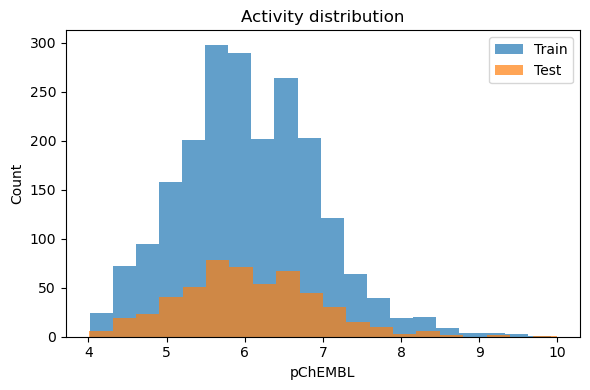

,index,chembl_id,smiles_raw,scaffold,y,mol,smiles
0,1,CHEMBL1767046,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...,,4.02,<rdkit.Chem.rdchem.Mol object at 0x00000268589...,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...
1,2,CHEMBL1469,O=C(O)CCCc1ccccc1,,4.03,<rdkit.Chem.rdchem.Mol object at 0x00000268589...,O=C(O)CCCc1ccccc1
2,3,CHEMBL3605493,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x00000268589...,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...
3,4,CHEMBL1767047,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x00000268589...,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...
4,5,CHEMBL3605499,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...,,4.08,<rdkit.Chem.rdchem.Mol object at 0x00000268589...,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...


In [3]:
def summarize_split(name, df):
    print(
        f"{name}: n = {len(df)}, "
        f"pChEMBL = {df['y'].mean():.3f} ± {df['y'].std():.3f} "
        f"[{df['y'].min():.2f}, {df['y'].max():.2f}], "
        f"scaffolds = {df['scaffold'].nunique()}"
    )


summarize_split("Train", train_df)
summarize_split("Test", test_df)

shared = set(train_df["scaffold"]) & set(test_df["scaffold"])
shared.discard("")
print("Shared Murcko scaffolds:", len(shared))
if shared:
    raise AssertionError("Scaffold leakage between train and test.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(train_df["y"], bins=20, alpha=0.7, label="Train")
ax.hist(test_df["y"], bins=20, alpha=0.7, label="Test")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Count")
ax.set_title("Activity distribution")
ax.legend()
plt.tight_layout()
plt.show()

train_df.head()


## 3. PubChem fingerprints

PubChem/CACTVS structural keys (881 bits) via PaDEL `PubchemFingerprinter.xml`. The JAR is called with `subprocess` (list args), not `padelpy.padeldescriptor`: that wrapper splits paths on spaces and crashes when Java writes cp1251 to stderr on Russian Windows. Molecules are already MolVS-standardized, so extra PaDEL salt/nitro/tautomer cleanup is switched off. The same generator is used for train and test.


In [4]:
def _write_smi(path, smiles, names):
    with path.open("w", encoding="ascii", newline="\n") as fh:
        for smi, name in zip(smiles, names):
            fh.write(f"{smi}\t{name}\n")


def _decode_java(raw):
    if not raw:
        return ""
    for enc in ("utf-8", "cp1251", "cp866"):
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")


def padel_pubchem(smiles, names, tag):
    if not PUBCHEM_XML.is_file():
        raise FileNotFoundError(f"PaDEL PubChem XML not found: {PUBCHEM_XML.resolve()}")
    if not PADEL_JAR.is_file():
        raise FileNotFoundError(f"PaDEL JAR not found: {PADEL_JAR}")

    work = Path(tempfile.mkdtemp(prefix=f"hdac8_pubchem_{tag}_"))
    smi_path = work / f"{tag}.smi"
    csv_path = work / f"{tag}.csv"
    xml_path = work / "PubchemFingerprinter.xml"
    shutil.copy2(PUBCHEM_XML, xml_path)
    _write_smi(smi_path, smiles, names)

    # Call the JAR with a list (no string.split). padelpy.padeldescriptor
    # splits on spaces and then utf-8-decodes Java stderr; both fail here.
    cmd = [
        "java",
        "-Djava.awt.headless=true",
        "-Dfile.encoding=UTF-8",
        "-jar",
        str(PADEL_JAR),
        "-maxruntime",
        "-1",
        "-threads",
        "2",
        "-descriptortypes",
        str(xml_path),
        "-detectaromaticity",
        "-dir",
        str(smi_path),
        "-file",
        str(csv_path),
        "-fingerprints",
        "-retainorder",
    ]
    proc = subprocess.run(cmd, capture_output=True)
    stderr = _decode_java(proc.stderr)
    stdout = _decode_java(proc.stdout)

    if not csv_path.is_file() or csv_path.stat().st_size == 0:
        raise RuntimeError(
            f"PaDEL produced no output for {tag} (exit {proc.returncode}).\n"
            f"stderr:\n{stderr[:2000]}\nstdout:\n{stdout[:2000]}"
        )
    if proc.returncode != 0:
        print(f"PaDEL exited with {proc.returncode} for {tag}; CSV exists, continuing.")
        if stderr:
            print(stderr[:500])

    desc = pd.read_csv(csv_path)
    fp_cols = [c for c in desc.columns if c != "Name"]
    if len(fp_cols) != FP_SIZE:
        raise ValueError(f"Expected {FP_SIZE} PubChem bits, got {len(fp_cols)} columns")
    if len(desc) != len(smiles):
        raise ValueError(f"PaDEL returned {len(desc)} rows for {len(smiles)} molecules ({tag})")

    X = desc[fp_cols].to_numpy(dtype=np.float32)
    if not np.isfinite(X).all():
        raise ValueError(f"Non-finite PubChem bits in {tag}")
    return X


def fingerprints(mols, tag=None):
    mols = list(mols)
    smiles = [Chem.MolToSmiles(mol) for mol in mols]
    names = [f"mol_{i + 1}" for i in range(len(mols))]
    if tag is None:
        tag = f"n{len(mols)}"
    return padel_pubchem(smiles, names, tag)


X_tr = fingerprints(train_df["mol"], "train")
X_ts = fingerprints(test_df["mol"], "test")
y_tr = train_df["y"].to_numpy(dtype=np.float64)
y_ts = test_df["y"].to_numpy(dtype=np.float64)

if X_tr.shape[1] != FP_SIZE or X_ts.shape[1] != FP_SIZE:
    raise ValueError(f"Expected {FP_SIZE} PubChem bits, got train {X_tr.shape} / test {X_ts.shape}")

print("X_train:", X_tr.shape, "X_test:", X_ts.shape)
print("Mean on-bits / molecule: train {:.1f}, test {:.1f}".format(X_tr.sum(1).mean(), X_ts.sum(1).mean()))

np.savetxt(MODEL_DIR / "x_tr_PubChem.csv", X_tr, delimiter=",")
np.savetxt(MODEL_DIR / "x_ts_PubChem.csv", X_ts, delimiter=",")
np.savetxt(MODEL_DIR / "y_tr.csv", y_tr, delimiter=",")
np.savetxt(MODEL_DIR / "y_ts.csv", y_ts, delimiter=",")


X_train: (2092, 881) X_test: (524, 881)
Mean on-bits / molecule: train 157.5, test 153.7


## 4. Shared utilities

OECD-style metrics: R² on the training set, Q² from cross-validation, and external R² on the held-out scaffold test set.

**Applicability domain (AD).** PubChem bits are binary. Euclidean distance treats shared *off*-bits as similarity and is not the usual comparison for structural keys. The chemically appropriate metric is the Tanimoto (Jaccard) coefficient on on-bits, reported as a distance:

$$D_{\mathrm{Tanimoto}}(a,b) = 1 - T_c(a,b) = 1 - \frac{|A \cap B|}{|A \cup B|}$$

The AD threshold is $\bar{d} + 0.5\,\sigma$ of the nearest-neighbour $D_{\mathrm{Tanimoto}}$ values in the training set (k = 1). A query is inside the domain if its nearest training neighbour satisfies $D_{\mathrm{Tanimoto}} \le d_{\mathrm{limit}}$.

In-AD membership only means the compound is similar to the training fingerprint space. It is **not** proof that an individual prediction is reliable: in-AD compounds can still be mispredicted, and AD-filtered statistics describe the interpolative subset only.

Test-set predictions are appended to `models/PubChem/test_predictions.csv` immediately after each model is evaluated.


In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_t, mean_p = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    return float(2 * cov / denom) if denom else np.nan


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "CCC": ccc(y_true, y_pred),
    }


def tanimoto_distance(X, Y=None):
    """Pairwise D_Tanimoto = 1 - T_c for binary fingerprints.

    T_c(a, b) = |A ∩ B| / |A ∪ B|. Two all-zero vectors are treated as identical (T_c = 1).
    For binary vectors this is the Jaccard distance.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = X if Y is None else np.asarray(Y, dtype=np.float64)
    intersection = X @ Y.T
    x_pop = X.sum(axis=1, keepdims=True)
    y_pop = Y.sum(axis=1, keepdims=True)
    union = x_pop + y_pop.T - intersection
    tc = np.divide(intersection, union, out=np.ones_like(intersection), where=union > 0)
    return 1.0 - tc


def compute_ad(X_train, z=AD_Z):
    dist = tanimoto_distance(X_train)
    np.fill_diagonal(dist, np.inf)
    nn = dist.min(axis=1)
    limit = float(nn.mean() + z * nn.std(ddof=0))
    return limit, nn


def apply_ad(X_train, X_test, limit):
    dist = tanimoto_distance(X_test, X_train)
    nn = dist.min(axis=1)
    return nn <= limit, nn


def plot_obs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.scatter(y_true, y_pred, s=16, alpha=0.65, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], color="black", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed pChEMBL")
    ax.set_ylabel("Predicted pChEMBL")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax


def cv_r2_pruned(trial, factory, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for step, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        model = factory()
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


def run_study(name, objective, n_trials):
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=name)

    # Optuna's tqdm.notebook bar often fails in Jupyter Notebook 7
    # ("Error displaying widget: model not found"). Use core ipywidgets instead.
    bar = widgets.IntProgress(value=0, min=0, max=n_trials, description=name, bar_style="info")
    label = widgets.HTML(value="starting&hellip;")
    display(widgets.HBox([bar, label]))

    def on_trial(study, trial):
        bar.value = len(study.trials)
        if trial.state.name == "PRUNED":
            label.value = f"trial {trial.number} pruned; best CV R² = {study.best_value:.4f}"
        elif trial.value is not None:
            label.value = (
                f"trial {trial.number}: CV R² = {trial.value:.4f}; "
                f"best = {study.best_value:.4f} (trial {study.best_trial.number})"
            )
        if bar.value >= n_trials:
            bar.bar_style = "success"

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[on_trial])
    print(f"{name}: best CV R2 = {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


def evaluate_model(name, estimator, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=None, cv_fit_params=None):
    fit_params = fit_params or {}
    cv_fit_params = cv_fit_params or {}
    model = clone(estimator)
    model.fit(X_tr, y_tr, **fit_params)

    y_hat_tr = model.predict(X_tr)
    y_hat_cv = cross_val_predict(clone(estimator), X_tr, y_tr, cv=cv_final, n_jobs=1, params=cv_fit_params)
    y_hat_ts = model.predict(X_ts)

    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)

    coverage = float(in_ad.mean()) if len(in_ad) else np.nan
    if in_ad.any():
        ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad])
    else:
        ad_m = {k: np.nan for k in test_m}

    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": coverage,
    }

    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    if (~in_ad).any():
        axes[2].scatter(
            y_ts[~in_ad],
            y_hat_ts[~in_ad],
            s=28,
            facecolors="none",
            edgecolors="crimson",
            label="outside training space (AD)",
        )
        axes[2].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return model, row, {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}


def write_test_predictions(name, y_hat_ts):
    pred_table[f"pred_{name}"] = np.asarray(y_hat_ts)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Updated {MODEL_DIR / 'test_predictions.csv'} with pred_{name}")
    cols = ["chembl_id", "pchembl_obs", f"pred_{name}", "in_AD", "D_Tanimoto", "T_c"]
    display(pred_table[cols].head())


results = []
fitted = {}
preds = {}
studies = {}


Train NN D_Tanimoto: 0.061 ± 0.066
AD limit (mean + 0.5*SD): 0.094
Test compounds similar to training space: 0.784 (411/524)
in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.


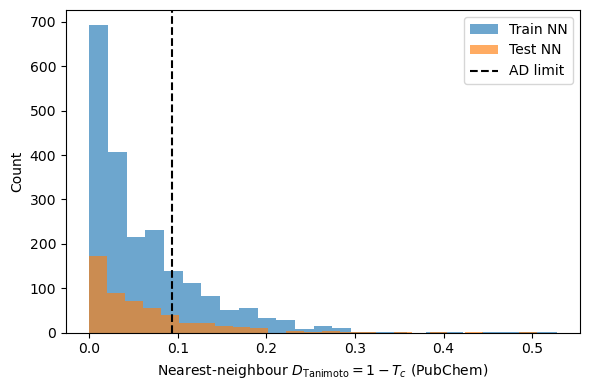

In [6]:
ad_limit, nn_train = compute_ad(X_tr)
in_ad, nn_test = apply_ad(X_tr, X_ts, ad_limit)

pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
pred_table["in_AD"] = in_ad
pred_table["D_Tanimoto"] = nn_test
pred_table["T_c"] = 1.0 - nn_test
pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

print(f"Train NN D_Tanimoto: {nn_train.mean():.3f} ± {nn_train.std():.3f}")
print(f"AD limit (mean + {AD_Z}*SD): {ad_limit:.3f}")
print(f"Test compounds similar to training space: {in_ad.mean():.3f} ({in_ad.sum()}/{len(in_ad)})")
print("in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nn_train, bins=25, alpha=0.65, label="Train NN")
ax.hist(nn_test, bins=25, alpha=0.65, label="Test NN")
ax.axvline(ad_limit, color="black", ls="--", label="AD limit")
ax.set_xlabel(r"Nearest-neighbour $D_{\mathrm{Tanimoto}} = 1 - T_c$ (PubChem)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. CatBoost

Trees do not need scaling. Search space covers depth, learning rate, L2, leaf size and boosting rounds. Each trial is scored by mean 5-fold R² with median pruning.


CatBoost: best CV R2 = 0.5546
Best params: {'depth': 10, 'learning_rate': 0.0811062664768165, 'l2_leaf_reg': 2.0514223831216305, 'min_data_in_leaf': 1, 'iterations': 800}
model          CatBoost
R2_train       0.966513
RMSE_train     0.161518
Q2_CV          0.555041
RMSE_CV        0.588765
MAE_CV         0.424084
R2_ext         0.576255
RMSE_ext       0.582059
MAE_ext        0.423473
CCC_ext        0.741018
R2_ext_AD      0.667293
RMSE_ext_AD    0.514843
AD_coverage    0.784351


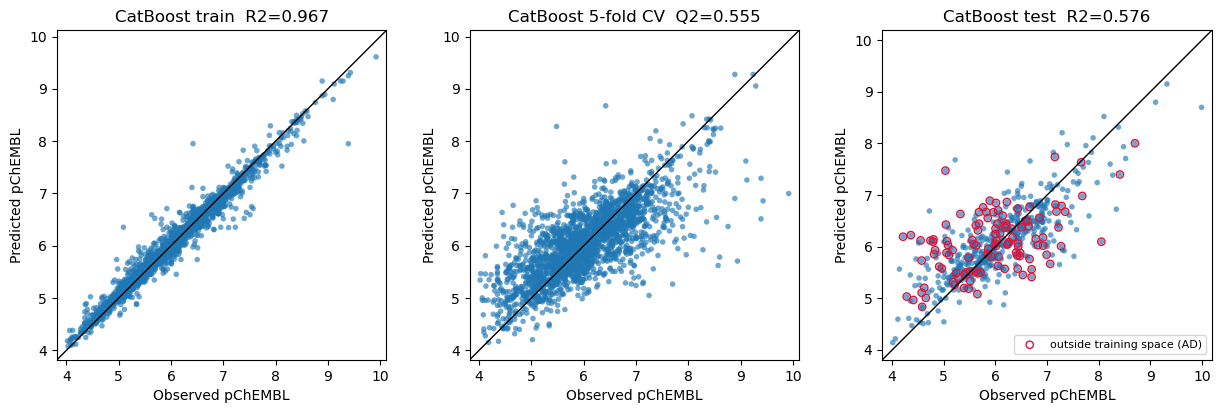

Updated models\PubChem\test_predictions.csv with pred_CatBoost


,chembl_id,pchembl_obs,pred_CatBoost,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.140800,True,0.053892,0.946108
1,CHEMBL3605494,4.06,4.214621,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.594287,True,0.025157,0.974843
3,CHEMBL5571764,4.14,5.565174,True,0.077381,0.922619
4,CHEMBL3771210,4.21,6.192179,False,0.360544,0.639456


['models\\PubChem\\CatBoost_PubChem.pkl']

In [7]:
def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
        "iterations": trial.suggest_int("iterations", 200, 1000, step=100),
        "random_seed": SEED,
        "verbose": False,
        "loss_function": "RMSE",
        "allow_writing_files": False,
    }
    return cv_r2_pruned(trial, lambda: CatBoostRegressor(**params), X_tr, y_tr, cv_search)


studies["CatBoost"] = run_study("CatBoost", objective_catboost, N_TRIALS["CatBoost"])
best_cat = CatBoostRegressor(
    **studies["CatBoost"].best_params,
    random_seed=SEED,
    verbose=False,
    loss_function="RMSE",
    allow_writing_files=False,
)
cat_fit = {"verbose": False}
fitted["CatBoost"], row, preds["CatBoost"] = evaluate_model(
    "CatBoost", best_cat, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=cat_fit, cv_fit_params=cat_fit
)
results.append(row)
joblib.dump(fitted["CatBoost"], MODEL_DIR / "CatBoost_PubChem.pkl")


## 5.1 SHAP descriptor importance

TreeSHAP on the fitted CatBoost model and the training PubChem matrix, as in the previous notebook. Bits are named `PubchemFP0`–`PubchemFP880`. Mean |SHAP| is written to `models/PubChem/shap_importance_CatBoost.csv`.


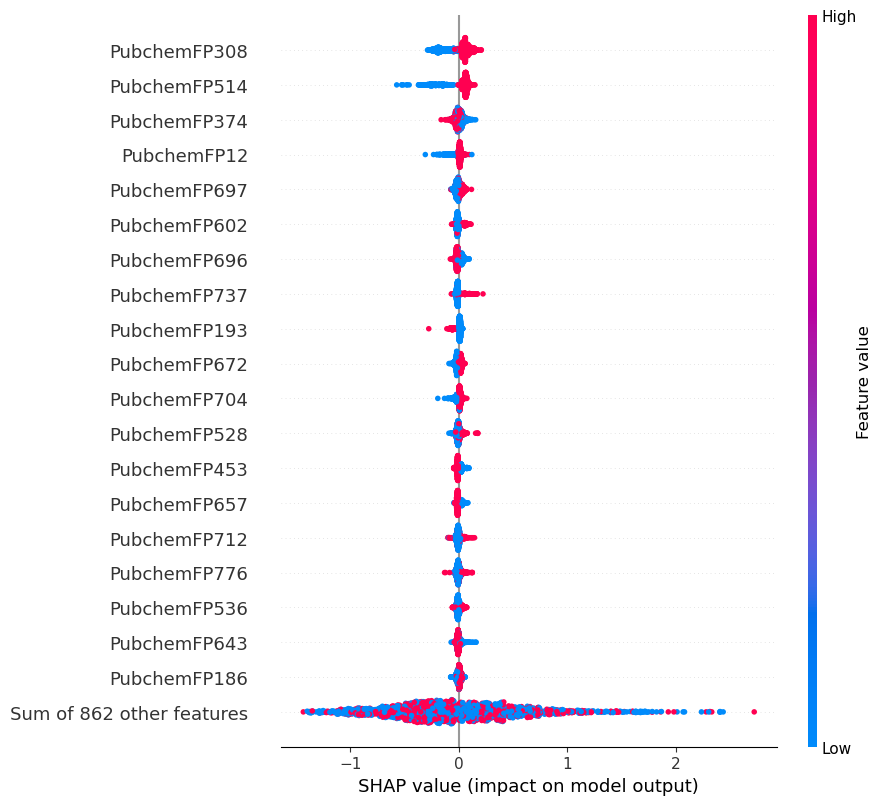

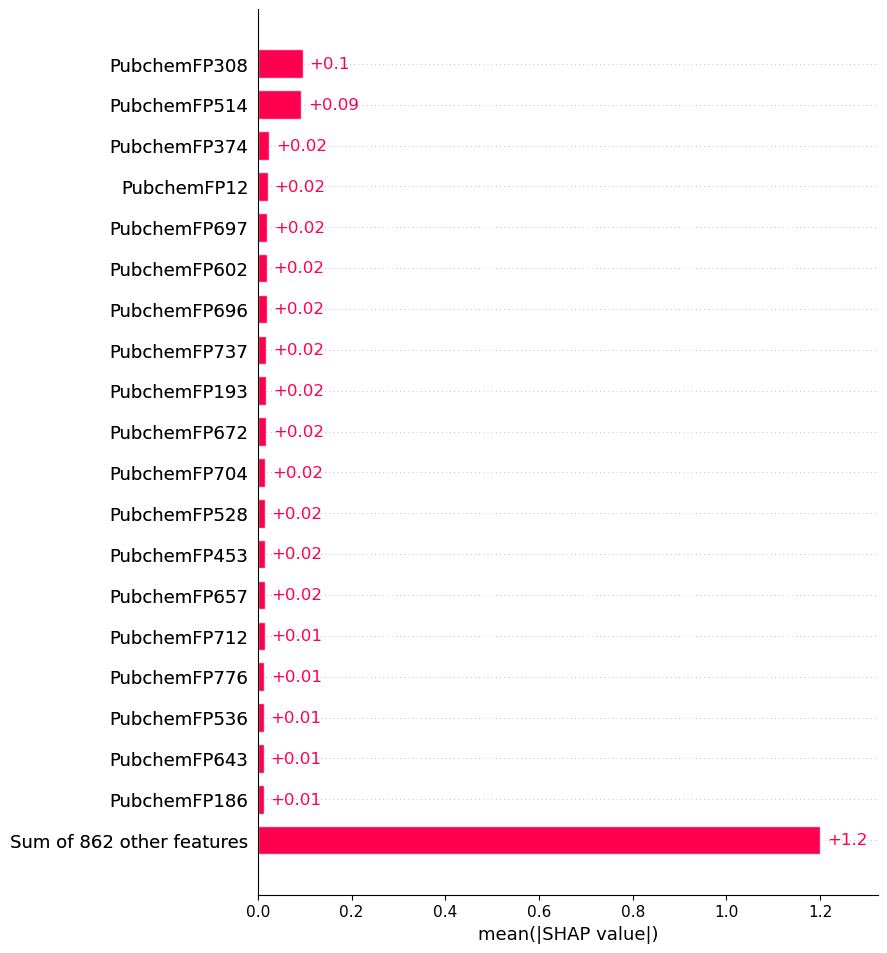

,descriptor,mean_abs_SHAP
0,PubchemFP308,0.095567
1,PubchemFP514,0.092612
2,PubchemFP374,0.024504
3,PubchemFP12,0.020605
4,PubchemFP697,0.019859
5,PubchemFP602,0.019102
6,PubchemFP696,0.018896
7,PubchemFP737,0.018397
8,PubchemFP193,0.018250
9,PubchemFP672,0.017784


In [8]:
import shap

fp_names = [f"PubchemFP{i}" for i in range(X_tr.shape[1])]
X_tr_shap = pd.DataFrame(X_tr, columns=fp_names)
explainer = shap.Explainer(fitted["CatBoost"])
shap_values = explainer(X_tr_shap)

shap.plots.beeswarm(shap_values, max_display=20)
shap.plots.bar(shap_values, max_display=20)

shap_importance = (
    pd.DataFrame(
        {
            "descriptor": fp_names,
            "mean_abs_SHAP": np.abs(shap_values.values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_SHAP", ascending=False)
    .reset_index(drop=True)
)
shap_importance.to_csv(MODEL_DIR / "shap_importance_CatBoost.csv", index=False)
display(shap_importance.head(20))


## 6. Support vector regression

RBF-SVR inside a `Pipeline` with `StandardScaler`, so scaling is fit only on each CV training fold. `C`, `gamma` and `epsilon` are searched on a log/linear scale covering the old grid and intermediate values.


SVR: best CV R2 = 0.4763
Best params: {'C': 2.6870239798129836, 'gamma': 0.004153342721202765, 'epsilon': 0.17783283693150076}
model               SVR
R2_train       0.912789
RMSE_train     0.260656
Q2_CV          0.476874
RMSE_CV        0.638388
MAE_CV         0.470629
R2_ext         0.481399
RMSE_ext       0.643919
MAE_ext        0.469638
CCC_ext        0.648962
R2_ext_AD      0.566532
RMSE_ext_AD    0.587655
AD_coverage    0.784351


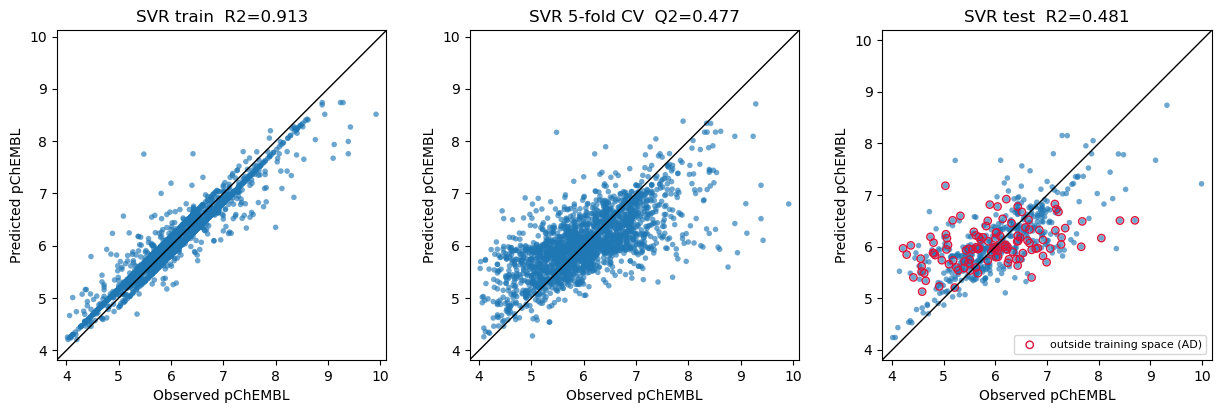

Updated models\PubChem\test_predictions.csv with pred_SVR


,chembl_id,pchembl_obs,pred_SVR,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.239210,True,0.053892,0.946108
1,CHEMBL3605494,4.06,4.240361,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.431649,True,0.025157,0.974843
3,CHEMBL5571764,4.14,5.523528,True,0.077381,0.922619
4,CHEMBL3771210,4.21,5.967358,False,0.360544,0.639456


['models\\PubChem\\SVM_PubChem.pkl']

In [9]:
def make_svr(C, gamma, epsilon):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon, cache_size=500)),
        ]
    )


def objective_svr(trial):
    C = trial.suggest_float("C", 0.1, 1e4, log=True)
    gamma = trial.suggest_float("gamma", 1e-6, 1e-1, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 0.5)
    return cv_r2_pruned(trial, lambda: make_svr(C, gamma, epsilon), X_tr, y_tr, cv_search)


studies["SVR"] = run_study("SVR", objective_svr, N_TRIALS["SVR"])
best_svr = make_svr(**studies["SVR"].best_params)
fitted["SVR"], row, preds["SVR"] = evaluate_model("SVR", best_svr, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["SVR"], MODEL_DIR / "SVM_PubChem.pkl")


## 7. Multi-layer perceptron

The previous grid mixed oversized networks (`(400, 300, 200, 100)`) with `lbfgs`/`sgd` and was too expensive for ~2k × 881 inputs. Search is limited to 1–3 hidden layers, Adam, L2 and learning rate, with early stopping.


MLP: best CV R2 = 0.3087
Best params: {'n_layers': 3, 'n_units': 128, 'activation': 'relu', 'alpha': 4.937319863056754e-05, 'learning_rate_init': 0.002342453816080896}
model               MLP
R2_train       0.890463
RMSE_train      0.29212
Q2_CV          0.310581
RMSE_CV        0.732864
MAE_CV         0.534866
R2_ext         0.382434
RMSE_ext       0.702678
MAE_ext        0.510851
CCC_ext         0.64553
R2_ext_AD      0.454142
RMSE_ext_AD    0.659453
AD_coverage    0.784351


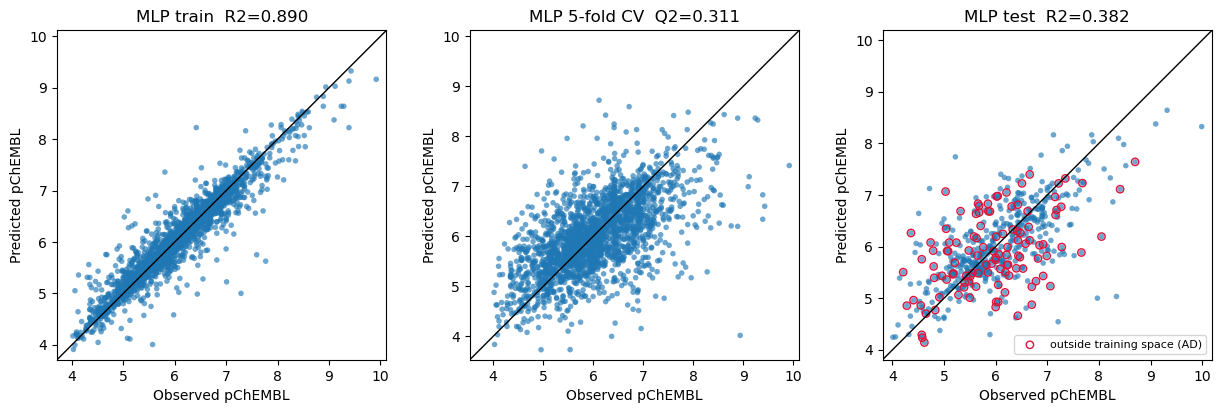

Updated models\PubChem\test_predictions.csv with pred_MLP


,chembl_id,pchembl_obs,pred_MLP,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.246768,True,0.053892,0.946108
1,CHEMBL3605494,4.06,4.251690,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.483627,True,0.025157,0.974843
3,CHEMBL5571764,4.14,5.391626,True,0.077381,0.922619
4,CHEMBL3771210,4.21,5.505869,False,0.360544,0.639456


['models\\PubChem\\MLPR_PubChem.pkl']

In [10]:
def make_mlp(n_layers, n_units, activation, alpha, learning_rate_init):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=tuple([n_units] * n_layers),
                    activation=activation,
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    solver="adam",
                    max_iter=400,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=15,
                    random_state=SEED,
                ),
            ),
        ]
    )


def objective_mlp(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units = trial.suggest_int("n_units", 32, 256, step=32)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    lr = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    return cv_r2_pruned(
        trial, lambda: make_mlp(n_layers, n_units, activation, alpha, lr), X_tr, y_tr, cv_search
    )


studies["MLP"] = run_study("MLP", objective_mlp, N_TRIALS["MLP"])
best_mlp = make_mlp(**studies["MLP"].best_params)
fitted["MLP"], row, preds["MLP"] = evaluate_model("MLP", best_mlp, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["MLP"], MODEL_DIR / "MLPR_PubChem.pkl")


## 8. k-nearest neighbors

`n_neighbors`, `weights` and distance metric are optimized. Jaccard (Tanimoto distance on binary bits) is included because it is more appropriate for PubChem fingerprints than Euclidean-only search. The old notebook also overwrote `x_ts` with training fingerprints; predictions now always use `X_ts`.


kNN: best CV R2 = 0.4799
Best params: {'n_neighbors': 9, 'weights': 'distance', 'metric': 'cosine'}
model               kNN
R2_train       0.982055
RMSE_train     0.118238
Q2_CV          0.479277
RMSE_CV        0.636921
MAE_CV         0.454742
R2_ext         0.506645
RMSE_ext        0.62805
MAE_ext        0.455504
CCC_ext        0.689974
R2_ext_AD      0.590371
RMSE_ext_AD    0.571267
AD_coverage    0.784351


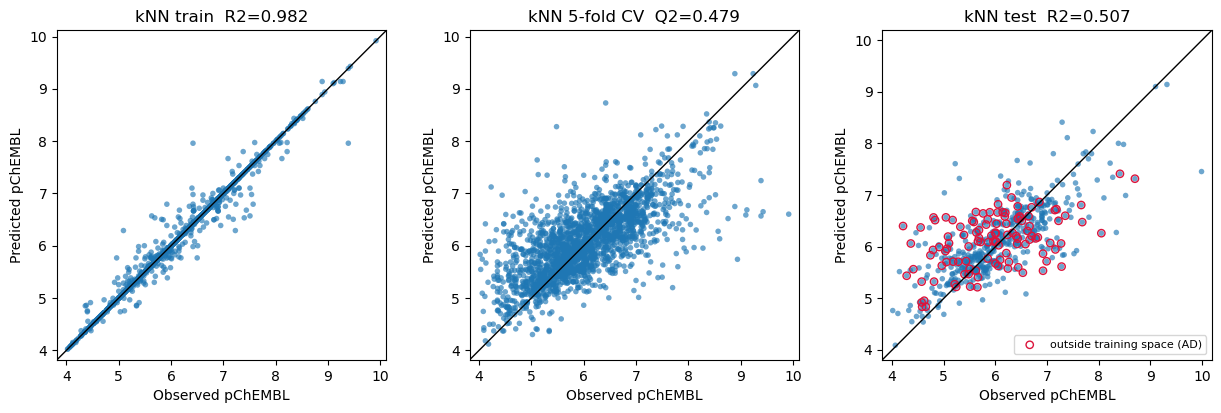

Updated models\PubChem\test_predictions.csv with pred_kNN


,chembl_id,pchembl_obs,pred_kNN,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.762129,True,0.053892,0.946108
1,CHEMBL3605494,4.06,4.090059,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.705588,True,0.025157,0.974843
3,CHEMBL5571764,4.14,5.516245,True,0.077381,0.922619
4,CHEMBL3771210,4.21,6.398766,False,0.360544,0.639456


['models\\PubChem\\kNN_PubChem.pkl']

In [11]:
def make_knn(n_neighbors, weights, metric):
    return KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, metric=metric, n_jobs=-1)


def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 31)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "jaccard", "cosine"])
    return cv_r2_pruned(trial, lambda: make_knn(n_neighbors, weights, metric), X_tr, y_tr, cv_search)


studies["kNN"] = run_study("kNN", objective_knn, N_TRIALS["kNN"])
best_knn = make_knn(**studies["kNN"].best_params)
fitted["kNN"], row, preds["kNN"] = evaluate_model("kNN", best_knn, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["kNN"], MODEL_DIR / "kNN_PubChem.pkl")


## 9. Model comparison

Metrics are rounded to two decimals to match the manuscript table: training R²/RMSE, 5-fold Q²cv/RMSE, external Q²test/RMSE (all test compounds), AD coverage (Cov), Q²test/RMSE for compounds inside the applicability domain, and a Tropsha-style validity flag (`valid_tropsha`: Q² > 0.5, R²_ext > 0.6, |R²_ext − Q²| < 0.3).

If the notebook kernel was restarted, metrics are loaded from `models/PubChem/metrics_summary.csv` so models do not need to be retrained.


Loaded cached metrics from models\PubChem\metrics_summary.csv


,R2,RMSE,Q2cv,RMSE,Q2test,RMSE,Cov,Q2test,RMSE,valid_tropsha
model,,,,,,,,,,
CatBoost,0.97,0.16,0.56,0.59,0.58,0.58,0.78,0.67,0.51,False
SVM,0.91,0.26,0.48,0.64,0.48,0.64,0.78,0.57,0.59,False
MLP,0.89,0.29,0.31,0.73,0.38,0.70,0.78,0.45,0.66,False
kNN,0.98,0.12,0.48,0.64,0.51,0.63,0.78,0.59,0.57,False


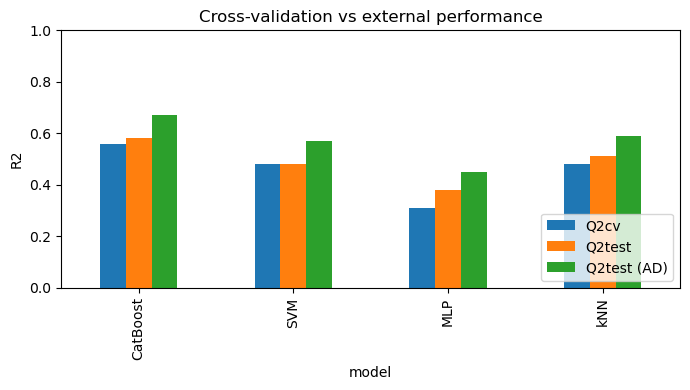

Best single model by external R2: CatBoost


In [3]:
metrics_path = MODEL_DIR / "metrics_summary.csv"

if "results" in globals() and results:
    summary = pd.DataFrame(results).set_index("model")
elif metrics_path.is_file():
    summary = pd.read_csv(metrics_path, index_col="model")
    print(f"Loaded cached metrics from {metrics_path}")
else:
    raise RuntimeError("No metrics in memory and no cached metrics_summary.csv found.")

summary = summary.drop(index=["Consensus"], errors="ignore")
summary["valid_tropsha"] = (
    (summary["Q2_CV"] > 0.5)
    & (summary["R2_ext"] > 0.6)
    & ((summary["R2_ext"] - summary["Q2_CV"]).abs() < 0.3)
)

TABLE_COLS = [
    "R2_train",
    "RMSE_train",
    "Q2_CV",
    "RMSE_CV",
    "R2_ext",
    "RMSE_ext",
    "AD_coverage",
    "R2_ext_AD",
    "RMSE_ext_AD",
]
TABLE_HEADERS = [
    "R2",
    "RMSE",
    "Q2cv",
    "RMSE",
    "Q2test",
    "RMSE",
    "Cov",
    "Q2test",
    "RMSE",
]
DISPLAY_NAMES = {"SVR": "SVM"}

table = summary[TABLE_COLS].copy()
table.index = table.index.map(lambda name: DISPLAY_NAMES.get(name, name))
table.columns = TABLE_HEADERS
table = table.round(2)
table["valid_tropsha"] = summary["valid_tropsha"].values

display(table)

fig, ax = plt.subplots(figsize=(7, 4))
summary[["Q2_CV", "R2_ext", "R2_ext_AD"]].round(2).rename(
    index=DISPLAY_NAMES,
    columns={"Q2_CV": "Q2cv", "R2_ext": "Q2test", "R2_ext_AD": "Q2test (AD)"},
).plot(kind="bar", ax=ax)
ax.set_ylabel("R2")
ax.set_ylim(0, 1)
ax.set_title("Cross-validation vs external performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = summary["R2_ext"].idxmax()
print("Best single model by external R2:", DISPLAY_NAMES.get(best_name, best_name))

table.to_csv(metrics_path)
if "studies" in globals() and studies:
    joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
    joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")


## 10. Y-randomization

`permutation_test_score` shuffles the training endpoint and repeats CV. A real structure–activity relationship should give a high true Q² and a near-zero (or negative) mean randomized score with a small p-value.


In [14]:
y_rand_rows = []
for name, est in fitted.items():
    perm_kwargs = {}
    if name == "CatBoost":
        perm_kwargs["params"] = {"verbose": False}
    score, perm_scores, pvalue = permutation_test_score(
        clone(est),
        X_tr,
        y_tr,
        cv=cv_final,
        scoring="r2",
        n_permutations=N_PERMUTATIONS,
        n_jobs=1 if name == "CatBoost" else -1,
        random_state=SEED,
        **perm_kwargs,
    )
    y_rand_rows.append(
        {
            "model": name,
            "true_Q2": score,
            "y_rand_mean": float(np.mean(perm_scores)),
            "y_rand_std": float(np.std(perm_scores)),
            "p_value": float(pvalue),
        }
    )
    print(
        f"{name}: true Q2 = {score:.3f}, "
        f"Y-randomization = {np.mean(perm_scores):.3f} ± {np.std(perm_scores):.3f}, "
        f"p = {pvalue:.4f}"
    )

y_rand = pd.DataFrame(y_rand_rows).set_index("model")
display(y_rand.round(4))
y_rand.round(4).to_csv(MODEL_DIR / "y_randomization.csv")


CatBoost: true Q2 = 0.555, Y-randomization = -0.314 ± 0.027, p = 0.0476
SVR: true Q2 = 0.476, Y-randomization = -0.213 ± 0.020, p = 0.0476
MLP: true Q2 = 0.309, Y-randomization = -0.384 ± 0.037, p = 0.0476
kNN: true Q2 = 0.480, Y-randomization = -0.253 ± 0.025, p = 0.0476


,true_Q2,y_rand_mean,y_rand_std,p_value
model,,,,
CatBoost,0.5546,-0.3142,0.0269,0.0476
SVR,0.4763,-0.2131,0.0201,0.0476
MLP,0.3087,-0.3836,0.0365,0.0476
kNN,0.4799,-0.2533,0.0255,0.0476
